<a href="https://colab.research.google.com/github/Krishishah7/ai-learning-series/blob/main/04_natural_language_processing/03_tf_idf.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TF-IDF (Term Frequency – Inverse Document Frequency)

Bag of Words represents documents by counting how many times each word appears. However, it gives equal importance to all words, even if some words appear in almost every document.

TF-IDF improves this by assigning higher weights to words that are frequent in a particular document but rare across the entire collection of documents.

The TF-IDF score is calculated by combining:

- **Term Frequency (TF):** How often a word appears in a document.
- **Inverse Document Frequency (IDF):** How unique or rare that word is across all documents.

Words that appear in many documents receive lower scores, while words that are more distinctive receive higher scores. This makes TF-IDF a more informative text representation than Bag of Words for many NLP tasks.

In [1]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
documents = [
    "I love machine learning",
    "Machine learning is amazing",
    "I love artificial intelligence"
]

for doc in documents:
    print(doc)

I love machine learning
Machine learning is amazing
I love artificial intelligence


In [3]:
tfidf_vectorizer = TfidfVectorizer()

tfidf_matrix = tfidf_vectorizer.fit_transform(documents)

In [4]:
print(tfidf_vectorizer.get_feature_names_out())

['amazing' 'artificial' 'intelligence' 'is' 'learning' 'love' 'machine']


In [5]:
tfidf_df = pd.DataFrame(
    tfidf_matrix.toarray(),
    columns=tfidf_vectorizer.get_feature_names_out()
)

tfidf_df

,amazing,artificial,intelligence,is,learning,love,machine
0,0.000000,0.000000,0.000000,0.000000,0.577350,0.57735,0.577350
1,0.562829,0.000000,0.000000,0.562829,0.428046,0.00000,0.428046
2,0.000000,0.622766,0.622766,0.000000,0.000000,0.47363,0.000000


In [6]:
count_vectorizer = CountVectorizer()

bow_matrix = count_vectorizer.fit_transform(documents)

bow_df = pd.DataFrame(
    bow_matrix.toarray(),
    columns=count_vectorizer.get_feature_names_out()
)

print("Bag of Words")
display(bow_df)

print("\nTF-IDF")
display(tfidf_df)

Bag of Words


,amazing,artificial,intelligence,is,learning,love,machine
0,0,0,0,0,1,1,1
1,1,0,0,1,1,0,1
2,0,1,1,0,0,1,0



TF-IDF


,amazing,artificial,intelligence,is,learning,love,machine
0,0.000000,0.000000,0.000000,0.000000,0.577350,0.57735,0.577350
1,0.562829,0.000000,0.000000,0.562829,0.428046,0.00000,0.428046
2,0.000000,0.622766,0.622766,0.000000,0.000000,0.47363,0.000000


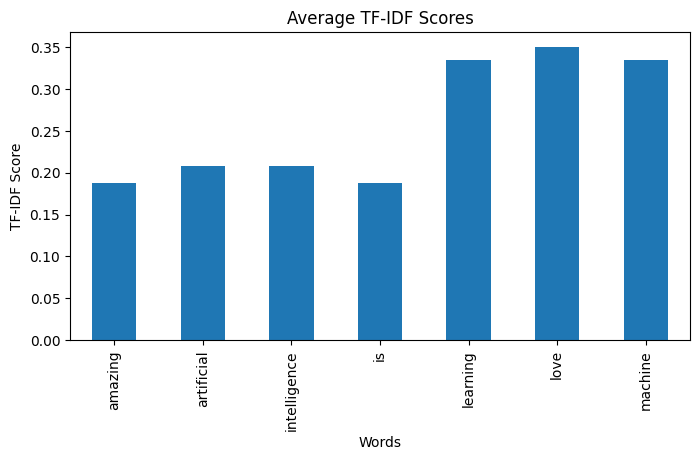

In [7]:
average_scores = tfidf_df.mean(axis=0)

plt.figure(figsize=(8,4))

average_scores.plot(kind="bar")

plt.title("Average TF-IDF Scores")
plt.xlabel("Words")
plt.ylabel("TF-IDF Score")

plt.show()

In [8]:
comparison = pd.DataFrame({

    "Bag of Words":[
        "Counts word frequency",
        "Equal importance to all words",
        "Simple representation",
        "Affected by common words"
    ],

    "TF-IDF":[
        "Uses weighted scores",
        "Highlights important words",
        "More informative representation",
        "Reduces influence of common words"
    ]

})

comparison

,Bag of Words,TF-IDF
0,Counts word frequency,Uses weighted scores
1,Equal importance to all words,Highlights important words
2,Simple representation,More informative representation
3,Affected by common words,Reduces influence of common words


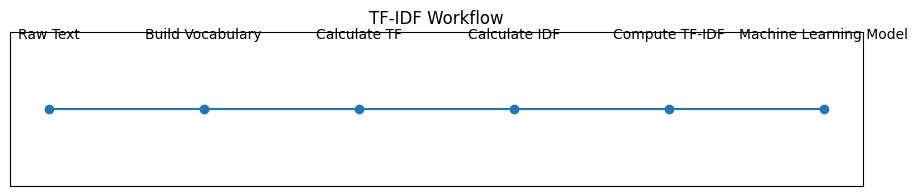

In [9]:
steps = [
    "Raw Text",
    "Build Vocabulary",
    "Calculate TF",
    "Calculate IDF",
    "Compute TF-IDF",
    "Machine Learning Model"
]

plt.figure(figsize=(11,2))

plt.plot(range(len(steps)), [1]*len(steps), marker="o")

for i, step in enumerate(steps):
    plt.text(i,1.05,step,ha="center")

plt.xticks([])
plt.yticks([])

plt.title("TF-IDF Workflow")

plt.show()